# Traffic Sign and Vehicle Detection using YOLOv8

Personal project demonstrating computer vision for road infrastructure.

## Results
- Real-time capable detection
- Tested on stop signs, traffic lights, cars, etc.

In [33]:
!pip install ultralytics opencv-python-headless supervision matplotlib -q

from ultralytics import YOLO
import cv2
import os
from IPython.display import display, Image
import matplotlib.pyplot as plt


--2026-06-06 21:45:09--  https://www.ilankelman.org/stopsigns/azerbaijan.jpg
Resolving www.ilankelman.org (www.ilankelman.org)... 35.212.20.163
Connecting to www.ilankelman.org (www.ilankelman.org)|35.212.20.163|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 86852 (85K) [image/jpeg]
Saving to: ‘stop_sign.jpg’

stop_sign.jpg       100%[===================>]  84.82K  --.-KB/s    in 0.06s   

2026-06-06 21:45:10 (1.49 MB/s) - ‘stop_sign.jpg’ saved [86852/86852]

Successfully downloaded and verified 'stop_sign.jpg'. Image shape: (841, 1300, 3)

image 1/1 /content/stop_sign.jpg: 416x640 2 cars, 1 traffic light, 2 stop signs, 149.7ms
Speed: 4.5ms preprocess, 149.7ms inference, 2.3ms postprocess per image at shape (1, 3, 416, 640)


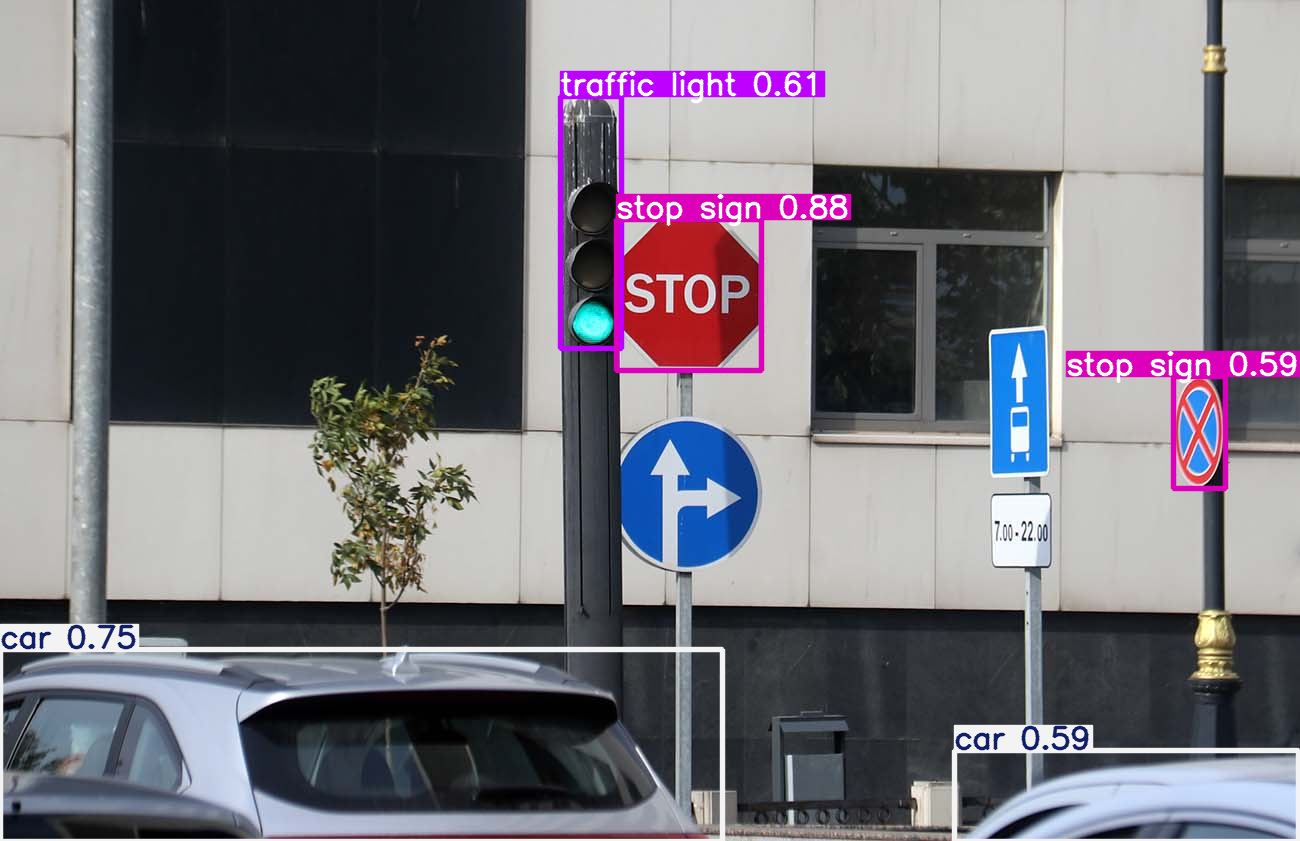

In [34]:
# A pre-trained model
model = YOLO("yolov8n.pt")

# A test traffic sign image
!wget https://www.ilankelman.org/stopsigns/azerbaijan.jpg -O stop_sign.jpg

# Verification of the downloaded image
image_path = "stop_sign.jpg"
if not os.path.exists(image_path):
    print(f"Error: Image file '{image_path}' was not downloaded.")
elif os.path.getsize(image_path) == 0:
    print(f"Error: Image file '{image_path}' was downloaded but is empty.")
else:
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: OpenCV could not read '{image_path}'. The file might be corrupted.")
    else:
        print(f"Successfully downloaded and verified '{image_path}'. Image shape: {img.shape}")
        results = model(image_path)
        results[0].show()

In [35]:
# === Upload your own video from Downloads ===
from google.colab import files

print("Please select your road video from your Downloads folder...")
uploaded = files.upload()

video_filename = list(uploaded.keys())[0]
print(f"✅ Uploaded: {video_filename}")

Please select your road video from your Downloads folder...


Saving trafficVideo.mp4 to trafficVideo (1).mp4
✅ Uploaded: trafficVideo (1).mp4


In [36]:
print(f"🚀 Running YOLOv8 detection on {video_filename}... (this may take 1–3 minutes depending on video length)")

# Inference and video saving
results = model.predict(
    video_filename,
    save=True,
    conf=0.4,
    verbose=False
)

print("✅ Processing complete!")
print(f"📁 Output video saved in: runs/detect/predict/{video_filename}")

🚀 Running YOLOv8 detection on trafficVideo (1).mp4... (this may take 1–3 minutes depending on video length)
WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results saved to /content/runs/detect/predict-2
✅ Processing complete!
📁 Output video saved in: runs/detect/predict/trafficVideo (1).mp4
